In [1]:
import pandas as pd

In [2]:
import random

In [3]:
COLORS = ["Red", "Blue", "Yellow", "Green"]

In [4]:
class Player:
    def __init__(self, name):
        self.name = name
        self.hand = []

    def add_card(self, card):
        self.hand.append(card)

    def remove_card(self, card):
        self.hand.remove(card)

    def hand_size(self):
        return len(self.hand)

    def has_won(self):
        return len(self.hand) == 0

    def show_hand(self):
        print(" | ".join(
            f'({i}) {card["value"]} {card["color"]}'
            for i, card in enumerate(self.hand, 1)
        ))

In [5]:
class UnoGame:
    def __init__(self, players):
        self.players = players
        self.deck = []
        self.used = []
        self.current_player = None
        self.last_played = None
        self.normal_order = True
        self.running = True
        self.winner = None
        self.current_color = None

    def create_deck(self):
        self.deck = []
        card_df = pd.read_csv("../data/data.csv")
        for _, row in card_df.iterrows():
            for _ in range(row["count"]):
                self.deck.append({
                    "color": row["color"],
                    "value": row["value"],
                    "effect": row["effect"]
                })


    
    def shuffle_deck(self):
        random.shuffle(self.deck)


    def deal_cards(self):
        for player in self.players:
            for _ in range(3):
                player.hand.append(self.deck.pop())

    def draw_card(self):
        if not self.deck:
            last_card = self.used.pop()
            self.deck = self.used
            random.shuffle(self.deck)
            self.used = [last_card]
        card = self.deck.pop()
        self.current_player.hand.append(card)
        return card

    def reset_hand(self):
        for player in self.players:
            player.hand = []


    def legal_cards(self):
        return [
            card for card in self.current_player.hand
            if (
                card["color"] == self.current_color
                or card["color"] == "Black"
                or card["value"] == self.last_played["value"]
            )
        ]

    def next_player(self):
        if self.current_player is None:
            self.current_player = random.choice(self.players)
            return

        index = self.players.index(self.current_player)

        if self.normal_order:
            self.current_player = self.players[
                (index + 1) % len(self.players)
            ]
        else:
            self.current_player = self.players[
                (index - 1) % len(self.players)
            ]

    def play_turn(self, choice=None):
        if choice is None:
            drawn_card = self.draw_card()
            if drawn_card in self.legal_cards():
                self.play_card(self.current_player.hand[-1])
            else:
                self.next_player()
            return

        success = self.play_card(choice)

        if success:
            self.check_winner()
            self.apply_effect()
            self.next_player()
            return True

        return False


    def check_winner(self):
        if len(self.current_player.hand) == 0:
            self.winner = self.current_player
            self.running = False
            return True

        return False

    def apply_effect(self):
        effect = self.last_played["effect"]

        if effect == "Skip":
            self.next_player()

        elif effect == "Reverse":
            self.normal_order = not self.normal_order

        elif effect == "Draw Two":
            self.next_player()
            self.draw_card()
            self.draw_card()

        elif effect == "Draw Four":
            new_color = self.ask_color()
            self.current_color = COLORS[new_color - 1]
            self.next_player()

            for _ in range(4):
                self.draw_card()

        elif effect == "Wild":
            new_color = self.ask_color()
            self.current_color = COLORS[new_color - 1]
            


    def play_card(self, choice):
        if not isinstance(choice, int):
            return False

        if choice < 1 or choice > len(self.current_player.hand):
            return False

        card = self.current_player.hand[choice - 1]

        if card not in self.legal_cards():
            return False

        played_card = self.current_player.hand.pop(choice - 1)

        self.used.append(played_card)
        self.last_played = played_card
        self.current_color = played_card["color"]

        self.check_winner()

        return True


    def setup_round(self):
        self.reset_hand()
        self.create_deck()
        self.shuffle_deck()
        self.deal_cards()

        first_card = self.deck.pop()

        self.used.append(first_card)
        self.last_played = first_card
        self.current_color = first_card["color"]

        self.next_player()

    def ask_card(self):
        while True:
            choice = input(
                f"Choose a card between 1 and {len(self.current_player.hand)} "
                "or 0 to draw: "
            )

            try:
                choice = int(choice)
            except ValueError:
                print("Please enter an integer.")
                continue

            if 0 <= choice <= len(self.current_player.hand):
                return choice

            print("Choice out of range.")


    def show_last_card(self):
        print(f" | {self.last_played["value"]}  {self.current_color} |")

    def ask_color(self):
        while True:
            choice = input(
                "Choose a color: "
                "1: Red | 2: Blue | 3: Yellow | 4: Green : "
            )

            try:
                choice = int(choice)
            except ValueError:
                print("Please enter an integer.")
                continue

            if 1 <= choice <= 4:
                return choice

            print("Choice out of range.")

In [6]:
P1 = Player("P1")
P2 = Player("P2")
P3 = Player("P3")
P4 = Player("P4")

players = [P1, P2, P3, P4]

In [7]:
game = UnoGame(players)

In [8]:
#game.setup_round()
#game.apply_effect()

In [9]:
#game.show_last_card()

In [10]:
"""print("Player's turn :", game.current_player.name)
for i in players:
    print(f"Cards in hand : {i.name} | {len(i.hand)}")
    
print("(0) Draw |")
game.current_player.show_hand()"""

'print("Player\'s turn :", game.current_player.name)\nfor i in players:\n    print(f"Cards in hand : {i.name} | {len(i.hand)}")\n\nprint("(0) Draw |")\ngame.current_player.show_hand()'

In [11]:
#game.play_turn(int(input("pick a card: ")))

In [12]:
from IPython.display import clear_output

game.setup_round()
game.apply_effect()

while game.running:
    game.show_last_card()

    print("Player's turn :", game.current_player.name)

    for player in players:
        print(f"Cards in hand : {player.name} | {len(player.hand)}")

    print("(0) Draw")
    game.current_player.show_hand()

    choice = game.ask_card()

    if choice == 0:
        game.play_turn()
    else:
        game.play_turn(choice)

    clear_output()

In [14]:
game.winner.name

'P1'

Counter({'P3': 257, 'P2': 253, 'P1': 248, 'P4': 242})
Time needed: 2.12 seconds for 1000 games


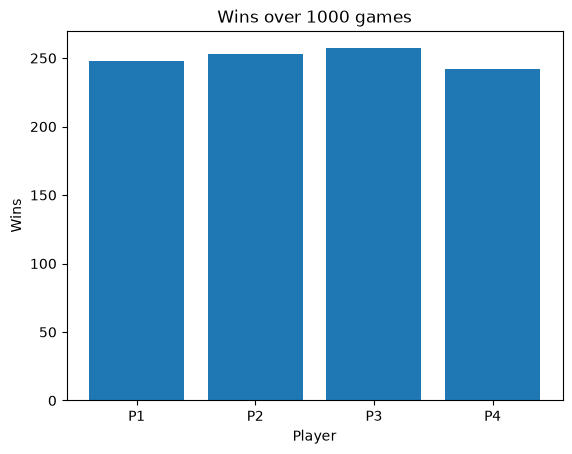

In [6]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from game import UnoGame, players
from game import UnoGame, players
from collections import Counter
import time
import matplotlib.pyplot as plt

logs = []
start_time = time.time()
ammount = 1000

for i in range(ammount):
    game = UnoGame(players)
    winner = game.run()
    logs.append(winner)
    #print(winner)
    #print("\n".join(game.logs))
end_time = time.time()
total_time = end_time - start_time
print(Counter(logs))
print(f"Time needed: {total_time:.2f} seconds for {ammount} games")

counts = Counter(logs)


plt.bar(counts.keys(), counts.values())
plt.xlabel("Player")
plt.ylabel("Wins")
plt.title("Wins over 1000 games")
plt.show()